# SVD Movie Search Engine — Extended Dataset Edition

A complete, step-by-step walkthrough of building a **semantic movie search engine** using Latent Semantic Analysis (LSA) powered by Singular Value Decomposition (SVD).

| Component | Method | Purpose |
|-----------|--------|---------|
| **Dataset** | CMU MovieSummaries + CoreNLP | 42 k movies with lemmatized, POS-tagged plots |
| **Corpus** | CoreNLP Lemmatized Text | POS-filtered base lemmas — cleaner vocabulary for LSA |
| **Vectorization** | TF-IDF | Sparse, term-weighted document vectors |
| **Dimensionality Reduction** | Truncated SVD | Latent Semantic Analysis — discover hidden topics |
| **Retrieval** | Cosine Similarity | Angle-based similarity in latent semantic space |

### What you will learn
1. **Why lemmatization matters** — how normalizing verb forms strengthens co-occurrence statistics
2. **What TF-IDF does** — balancing local term frequency against corpus-wide rarity
3. **What SVD produces** — decomposing $A$ into $U$, $\Sigma$, $V^T$ and what each matrix represents
4. **How LSA finds topics** — the bridge between matrix algebra and semantic retrieval
5. **Why cosine similarity** — angle vs. magnitude, and why it is the right metric for text

### Dataset
**CMU MovieSummaries** (~42 k movies joined from metadata + plot summaries) annotated with **Stanford CoreNLP** — the largest freely available lemmatized movie corpus.

> **Run order**: cells execute top to bottom. The lemma cache (`models/corenlp_lemma_cache.joblib`) loads automatically; CoreNLP parsing only runs once (~100 s) if no cache exists.

In [1]:
import gzip
import json
import os
import re
import warnings
from pathlib import Path
from xml.etree import ElementTree as ET

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

DATA_DIR        = Path("../data/external/MovieSummaries")
CORENLP_DIR     = Path("../data/external/corenlp_plot_summaries")
CACHE_PATH      = Path("../models/corenlp_lemma_cache.joblib")
ARTIFACT_V2_PATH = Path("../models/search_artifacts_v2.joblib")

print("Imports OK")
print(f"MovieSummaries: {DATA_DIR}")
print(f"CoreNLP dir   : {CORENLP_DIR}  ({len(list(CORENLP_DIR.glob('*.xml.gz')))} files)")


Imports OK
MovieSummaries: ../data/external/MovieSummaries
CoreNLP dir   : ../data/external/corenlp_plot_summaries  (42306 files)


## 1. Dataset — CMU MovieSummaries

### What is this dataset?

The **CMU Movie Summary Corpus** (released by Carnegie Mellon University) contains two files:

| File | Rows | Key columns |
|------|------|-------------|
| `movie.metadata.tsv` | 81,741 | title, release_date, genres (Freebase JSON), revenue, runtime |
| `plot_summaries.txt` | 42,303 | Wikipedia plot text, one movie per line |

Genres are stored as **Freebase JSON dicts**, e.g.:
```json
{"/m/01jfsb": "Thriller", "/m/07s9rl0": "Drama"}
```
We parse these into plain Python lists: `["Thriller", "Drama"]`.

### Why this dataset?

The Wikipedia CSV used in `main.ipynb` had only raw plain text. This dataset adds:
1. **Multi-label structured genres** — 57+ unique Freebase genres vs a single genre string
2. **CoreNLP annotations** — each plot has been pre-parsed by Stanford CoreNLP, providing lemmas + POS tags per token (stored as `.xml.gz` files)
3. **Larger coverage** — 42 k movies vs 34 k

### Join strategy

We perform an **inner join** on `wiki_id` — only movies that have **both** metadata and a plot summary are kept (~42 k clean records with no missing plots).

In [2]:
def _parse_freebase_dict(value) -> list[str]:
    """Parse a Freebase JSON dict like {'/m/01jfsb': 'Thriller'} into ['Thriller']."""
    if pd.isna(value) or not str(value).strip():
        return ["Unknown"]
    try:
        d = json.loads(str(value).replace("'", '"'))
        values = [v.strip() for v in d.values() if v and v.strip()]
        return values if values else ["Unknown"]
    except Exception:
        # Fall back: extract quoted strings
        parts = re.findall(r'"([^"]+)"', str(value))
        # Drop Freebase IDs (start with /m/)
        parts = [p for p in parts if not p.startswith("/m/")]
        return parts if parts else ["Unknown"]


def _parse_year(value) -> int | None:
    if pd.isna(value):
        return None
    m = re.search(r"(19\d{2}|20\d{2})", str(value))
    return int(m.group(1)) if m else None


# Load metadata
meta_raw = pd.read_csv(
    DATA_DIR / "movie.metadata.tsv", sep="\t", header=None,
    names=["wiki_id", "freebase_id", "title", "release_date",
           "revenue", "runtime", "languages", "countries", "genres"],
)

# Load plot summaries
plots_raw = pd.read_csv(
    DATA_DIR / "plot_summaries.txt", sep="\t", header=None,
    names=["wiki_id", "plot"],
)

# Inner join on wiki_id — only keep movies with BOTH metadata and a plot
df = pd.merge(
    meta_raw[["wiki_id", "title", "release_date", "genres"]],
    plots_raw,
    on="wiki_id",
    how="inner",
)

df["genre"]  = df["genres"].apply(_parse_freebase_dict)
df["year"]   = df["release_date"].apply(_parse_year)
df["plot"]   = df["plot"].fillna("").astype(str)
df["title"]  = df["title"].fillna("Unknown Title").astype(str)

df = df.drop(columns=["genres", "release_date"]).reset_index(drop=True)

print(f"Shape after join  : {df.shape}")
print(f"Columns           : {list(df.columns)}")
print(f"Year range        : {int(df['year'].min())} – {int(df['year'].max())}")
print(f"\nSample row:")
display(df.head(5))


Shape after join  : (42204, 5)
Columns           : ['wiki_id', 'title', 'plot', 'genre', 'year']
Year range        : 1900 – 2014

Sample row:


,wiki_id,title,plot,genre,year
0,975900,Ghosts of Mars,"Set in the second half of the 22nd century, th...","[Thriller, Science Fiction, Horror, Adventure,...",2001.0
1,9363483,White Of The Eye,A series of murders of rich young women throug...,"[Thriller, Erotic thriller, Psychological thri...",1987.0
2,261236,A Woman in Flames,"Eva, an upper class housewife, becomes frustra...",[Drama],1983.0
3,18998739,The Sorcerer's Apprentice,"Every hundred years, the evil Morgana returns...","[Family Film, Fantasy, Adventure, World cinema]",2002.0
4,6631279,Little city,"Adam, a San Francisco-based artist who works a...","[Romantic comedy, Ensemble Film, Comedy-drama,...",1997.0


## 2) Exploratory Data Analysis

Before building any model, we visualise:
- **Release year distribution** — shows temporal breadth of the corpus
- **Top genres** — confirms multi-label genre diversity
- **Plot word-count distribution** — critical for LSA quality: longer plots give richer TF-IDF vectors


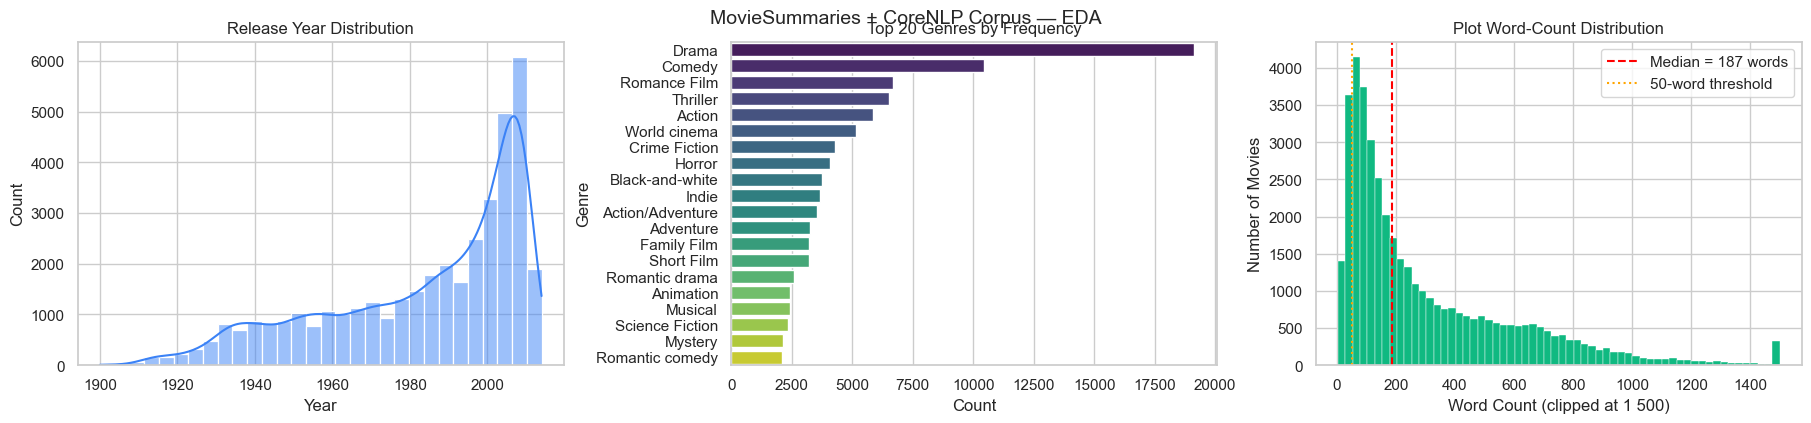

Plot word-count statistics:
count    42204.0
mean       310.7
std        318.2
min          4.0
5%          34.0
25%         87.0
50%        187.0
75%        453.0
95%        912.0
max       4929.0
Name: plot, dtype: float64

Movies with <50 words  : 4,458  (10.6%)
Movies with 50-300     : 22,445
Movies with 300+ words : 15,301  (36.3%)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

# --- Year distribution ---
ax = axes[0]
years_clean = df["year"].dropna()
sns.histplot(years_clean, bins=30, kde=True, ax=ax, color="#3B82F6")
ax.set_title("Release Year Distribution")
ax.set_xlabel("Year")
ax.set_ylabel("Count")

# --- Top genres ---
ax = axes[1]
genre_counts = df["genre"].explode().value_counts().head(20)
sns.barplot(x=genre_counts.values, y=genre_counts.index,
            hue=genre_counts.index, palette="viridis", legend=False, ax=ax)
ax.set_title("Top 20 Genres by Frequency")
ax.set_xlabel("Count")
ax.set_ylabel("Genre")

# --- Plot word-count distribution ---
ax = axes[2]
word_counts = df["plot"].str.split().str.len()
ax.hist(word_counts.clip(upper=1500), bins=60, color="#10B981", edgecolor="white", linewidth=0.3)
ax.axvline(word_counts.median(), color="red", ls="--", lw=1.5,
           label=f"Median = {int(word_counts.median())} words")
ax.axvline(50, color="orange", ls=":", lw=1.5, label="50-word threshold")
ax.set_title("Plot Word-Count Distribution")
ax.set_xlabel("Word Count (clipped at 1 500)")
ax.set_ylabel("Number of Movies")
ax.legend()

plt.suptitle("MovieSummaries + CoreNLP Corpus — EDA", fontsize=14, y=1.02)
plt.show()

# Numeric summary
wc_stat = word_counts.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(1)
print("Plot word-count statistics:")
print(wc_stat)
print(f"\nMovies with <50 words  : {(word_counts < 50).sum():,}  ({(word_counts < 50).mean()*100:.1f}%)")
print(f"Movies with 50-300     : {((word_counts >= 50) & (word_counts < 300)).sum():,}")
print(f"Movies with 300+ words : {(word_counts >= 300).sum():,}  ({(word_counts >= 300).mean()*100:.1f}%)")


## 3. What is a Lemmatized Corpus — and Why Does It Help LSA?

### What is Lemmatization?

**Lemmatization** reduces each word to its canonical base form — its **lemma**:

| Surface forms | Lemma |
|--------------|-------|
| runs, ran, running, runner | `run` |
| ghosts, ghostly | `ghost` |
| haunted, haunting, haunt | `haunt` |
| mysterious, mysteriously | `mysterious` |
| better | `good` |

Unlike **stemming** (which crudely chops suffixes: "running" → "runn"), lemmatization uses
linguistic morphological knowledge to produce real words ("running" → "run").

### Part-of-Speech (POS) Filtering

Beyond lemmatization, we also **filter by grammatical role**. CoreNLP assigns every token a Penn Treebank POS tag:

| POS group | Tags | Examples | Keep? |
|-----------|------|---------|-------|
| Nouns | NN, NNS, NNP, NNPS | detective, ghost, Mars | ✅ |
| Verbs | VB, VBD, VBG, VBN, VBP, VBZ | chase, haunted, escape | ✅ |
| Adjectives | JJ, JJR, JJS | mysterious, dark, older | ✅ |
| Adverbs | RB, RBR, RBS | quickly, very, rarely | ❌ |
| Determiners | DT | the, a, an | ❌ |
| Prepositions | IN | in, on, at, because | ❌ |
| Pronouns | PRP, WP | he, she, who | ❌ |
| Conjunctions | CC | and, or, but | ❌ |

**Only nouns, verbs, and adjectives carry thematic/semantic meaning.** The rest appear in virtually every document and add noise without discriminating power.

### How It Helps LSA

| Problem in raw text | How lemmatization fixes it |
|--------------------|-----------------------------|
| "run", "ran", "running" treated as 3 different features | All mapped to `run` — 1 feature with 3× co-occurrence count |
| "ghost" and "ghosts" counted separately | Both → `ghost` — stronger latent connection to "haunt", "house" |
| "the", "a", "of" swamp the vocabulary | Filtered by POS — not even included |
| Reduced vocabulary → denser TF-IDF matrix | SVD gets stronger, less noisy co-occurrence signal to factorize |

### How We Extract Lemmas from CoreNLP XML

Stanford CoreNLP pre-annotated each movie's plot summary. Results are stored as `.xml.gz` files — one per movie — each containing sentence and token annotations:

```xml
<token id="4">
  <word>haunted</word>
  <lemma>haunt</lemma>
  <POS>VBD</POS>
</token>
```

Our extraction pipeline per movie:
1. Open `{wiki_id}.xml.gz`
2. Iterate every `<token>` in the XML
3. Keep only tokens where: `POS ∈ CONTENT_POS` **and** `lemma.isalpha()` **and** `len(lemma) > 2`
4. Join filtered lemmas: `"haunt house ghost mysterious spirit"`
5. Prepend title + genre tokens for metadata signal

**Caching**: Parsing 42 k XML files takes ~100 s once. Results are saved to `models/corenlp_lemma_cache.joblib` and loaded instantly on every subsequent run.

In [5]:
CONTENT_POS = {
    "NN", "NNS", "NNP", "NNPS",          # nouns
    "VB", "VBD", "VBG", "VBN", "VBP", "VBZ",  # verbs
    "JJ", "JJR", "JJS",                   # adjectives
}


def _extract_lemmas_from_xml(path: Path) -> str:
    """Parse one CoreNLP XML.gz and return a space-joined string of content lemmas."""
    with gzip.open(path, "rb") as fh:
        tree = ET.parse(fh)
    tokens = []
    for tok in tree.getroot().iter("token"):
        lemma = tok.findtext("lemma", "").lower().strip()
        pos   = tok.findtext("POS", "")
        if pos in CONTENT_POS and lemma.isalpha() and len(lemma) > 2:
            tokens.append(lemma)
    return " ".join(tokens)


def build_lemma_corpus(df: pd.DataFrame, corenlp_dir: Path, cache_path: Path) -> list[str]:
    """Return a lemmatized corpus aligned with df rows.

    Loads from cache if available; otherwise parses all XML.gz files and saves cache.
    Movies with no matching CoreNLP file fall back to their raw plot text.
    """
    if cache_path.exists():
        print(f"Loading lemma cache from {cache_path} ...")
        return joblib.load(cache_path)

    print("Building lemma corpus from CoreNLP XML files (one-time, ~100 s) ...")
    wiki_id_to_lemmas: dict[int, str] = {}
    xml_files = list(corenlp_dir.glob("*.xml.gz"))
    total = len(xml_files)

    for i, path in enumerate(xml_files, 1):
        wiki_id = int(path.stem.split(".")[0])
        try:
            wiki_id_to_lemmas[wiki_id] = _extract_lemmas_from_xml(path)
        except Exception:
            wiki_id_to_lemmas[wiki_id] = ""
        if i % 5000 == 0 or i == total:
            print(f"  {i:>6}/{total} files processed", end="\r")

    print()
    corpus = []
    fallback = 0
    for _, row in df.iterrows():
        wid = int(row["wiki_id"])
        lemma_text = wiki_id_to_lemmas.get(wid, "")
        if lemma_text.strip():
            genre_str = " ".join(row["genre"]) if isinstance(row["genre"], list) else str(row["genre"])
            doc = f"{row['title'].lower()} {genre_str.lower()} {lemma_text}"
        else:
            # Fallback: use raw plot
            genre_str = " ".join(row["genre"]) if isinstance(row["genre"], list) else str(row["genre"])
            doc = f"{row['title']} {genre_str} {row['plot']}".lower()
            fallback += 1
        corpus.append(doc)

    cache_path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(corpus, cache_path)
    print(f"Cached to {cache_path}  (fallback to raw text: {fallback} movies)")
    return corpus


lemma_corpus = build_lemma_corpus(df, CORENLP_DIR, CACHE_PATH)

print(f"\nLemma corpus size : {len(lemma_corpus):,} documents")
print(f"\nSample lemmatized doc (first 400 chars):")
print(lemma_corpus[0][:400])


Loading lemma cache from ../models/corenlp_lemma_cache.joblib ...

Lemma corpus size : 42,204 documents

Sample lemmatized doc (first 400 chars):
ghosts of mars thriller science fiction horror adventure supernatural action space western set second half century film depict mars planet have terraform allow human walk surface wear pressure suit martian society have become matriarchal woman most position authority story concern police officer melanie ballard second command small team sergeant jericho send pick transport prisoner name desolation


In [6]:
# ── Before / After: Raw text vs Lemmatized document ───────────────────────────
print("Lemmatization Effect — 3 Movie Examples")
print("=" * 70)

for i in [0, 100, 500]:
    row = df.iloc[i]
    raw_doc   = f"{row['title']} {' '.join(row['genre']) if isinstance(row['genre'], list) else row['genre']} {row['plot']}"
    lemma_doc = lemma_corpus[i]

    raw_words   = raw_doc.lower().split()
    lemma_words = lemma_doc.split()

    print(f"\n  Movie #{i}: {row['title']} ({int(row['year']) if pd.notna(row['year']) else '?'})")
    print(f"  Genre  : {', '.join(row['genre'][:3]) if isinstance(row['genre'], list) else row['genre']}")
    print(f"\n  Raw text (first 35 tokens):")
    print(f"    {' '.join(raw_words[:35])}...")
    print(f"\n  Lemmatized (first 35 tokens):")
    print(f"    {' '.join(lemma_words[:35])}...")
    print(f"\n  Raw word count    : {len(raw_words):,}")
    print(f"  Lemma token count : {len(lemma_words):,}  "
          f"({(1 - len(lemma_words)/len(raw_words))*100:.0f}% reduction)")
    print("-" * 70)

Lemmatization Effect — 3 Movie Examples

  Movie #0: Ghosts of Mars (2001)
  Genre  : Thriller, Science Fiction, Horror

  Raw text (first 35 tokens):
    ghosts of mars thriller science fiction horror adventure supernatural action space western set in the second half of the 22nd century, the film depicts mars as a planet that has been 84% terraformed, allowing humans...

  Lemmatized (first 35 tokens):
    ghosts of mars thriller science fiction horror adventure supernatural action space western set second half century film depict mars planet have terraform allow human walk surface wear pressure suit martian society have become matriarchal woman...

  Raw word count    : 369
  Lemma token count : 200  (46% reduction)
----------------------------------------------------------------------

  Movie #100: Thunderbolt (1910)
  Genre  : Short Film, Indie

  Raw text (first 35 tokens):
    thunderbolt short film indie frederick ward is a cattle drover earning money for his wedding when he is

## 4. Text Representation — TF-IDF

### What is TF-IDF?

**Term Frequency – Inverse Document Frequency** converts raw text into numerical vectors suitable for mathematical operations like SVD. Each document becomes a sparse vector in a high-dimensional vocabulary space.

For each term $t$ in document $d$ across a corpus of $N$ documents:

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

**Term Frequency (TF)** — how often term $t$ appears in document $d$. We use **sublinear TF** to dampen the dominance of very frequent terms:

$$\text{TF}_{\text{sublinear}}(t, d) = 1 + \log(\text{count}(t, d))$$

This means going from 1→10 occurrences adds 1 unit, but going from 10→100 also only adds 1 unit — preventing a few repeated words from drowning out the rest.

**Inverse Document Frequency (IDF)** — how rare term $t$ is across all documents:

$$\text{IDF}(t) = \log\frac{N}{\text{DF}(t)}$$

where $\text{DF}(t)$ = number of documents containing term $t$.

| Term | DF | IDF (N=42,303) | Meaning |
|------|----|---------------|---------|
| `haunt` | ~600 | log(42303/600) ≈ 4.25 | Discriminating — marks horror/supernatural |
| `detective` | ~900 | log(42303/900) ≈ 3.85 | Discriminating — marks mystery/crime |
| `film` | ~35,000 | log(42303/35000) ≈ 0.19 | Near-universal — almost useless |

### Why TF-IDF Instead of Raw Counts?

| Problem with raw counts | How TF-IDF fixes it |
|-------------------------|---------------------|
| "film", "story" appear in every document | IDF ≈ 0 — effectively zeroed out |
| Long plots dominate short ones | TF normalization by document length |
| One very repeated word dominates | Sublinear TF dampens repetition |
| "haunted" and "haunt" are separate features | Already fixed by lemmatization |

### Configuration Used

| Parameter | Value | Reason |
|-----------|-------|--------|
| `stop_words` | `"english"` | Remove 318 English function words (the, is, at…) |
| `sublinear_tf` | `True` | $1 + \log(\text{tf})$ — prevent term dominance |
| `min_df` | `3` | Remove hapax legomena — terms in fewer than 3 docs are too rare to generalize |
| `max_df` | `0.90` | Remove near-universal terms — in 90%+ docs, adds no discriminating signal |
| `ngram_range` | `(1, 2)` | Include bigrams: `"haunted house"`, `"serial killer"`, `"outer space"` are unambiguous as phrases |

### The Result: A Sparse Matrix

After vectorization, we have a matrix $A$ of shape $(42{,}303 \text{ movies} \times V \text{ terms})$. This matrix is extremely **sparse** — most movies use only a tiny fraction of the full vocabulary. SVD will compress this into a dense low-rank approximation.

In [7]:
TFIDF_PARAMS = dict(
    stop_words="english",
    sublinear_tf=True,
    min_df=3,
    max_df=0.90,
    ngram_range=(1, 2),
)

tfidf   = TfidfVectorizer(**TFIDF_PARAMS)
X_tfidf = tfidf.fit_transform(lemma_corpus)
feature_names = tfidf.get_feature_names_out()

n, v = X_tfidf.shape
sparsity = round((1 - X_tfidf.nnz / (n * v)) * 100, 2)

print(f"TF-IDF matrix : {n:,} docs × {v:,} terms")
print(f"Non-zero cells: {X_tfidf.nnz:,}  (only {100 - sparsity:.2f}% filled)")
print(f"Sparsity      : {sparsity}%")

print(f"\nTop 10 most discriminating terms (highest IDF):")
idf_values = tfidf.idf_
top_idf_idx = np.argsort(idf_values)[-10:][::-1]
for i in top_idf_idx:
    print(f"  {feature_names[i]:35s}  IDF = {idf_values[i]:.4f}")

print(f"\nTop 10 most universal terms (lowest IDF — least discriminating):")
low_idf_idx = np.argsort(idf_values)[:10]
for i in low_idf_idx:
    print(f"  {feature_names[i]:35s}  IDF = {idf_values[i]:.4f}")

TF-IDF matrix : 42,204 docs × 341,039 terms
Non-zero cells: 6,470,623  (only 0.04% filled)
Sparsity      : 99.96%

Top 10 most discriminating terms (highest IDF):
  était                                IDF = 10.2640
  lake george                          IDF = 10.2640
  lake mountain                        IDF = 10.2640
  lake morning                         IDF = 10.2640
  lake miss                            IDF = 10.2640
  lake lie                             IDF = 10.2640
  lake join                            IDF = 10.2640
  lake jessica                         IDF = 10.2640
  lake investigate                     IDF = 10.2640
  lake home                            IDF = 10.2640

Top 10 most universal terms (lowest IDF — least discriminating):
  film                                 IDF = 1.4617
  drama                                IDF = 1.7480
  leave                                IDF = 2.0611
  make                                 IDF = 2.0630
  man                            

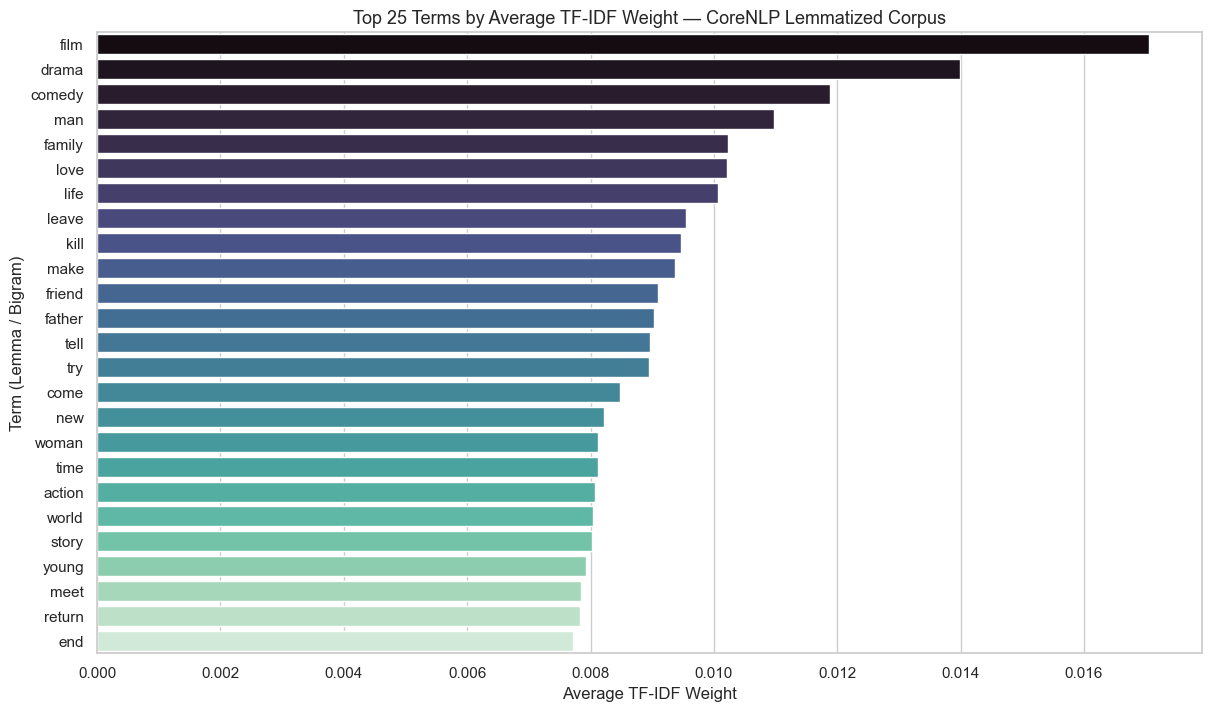

Observations:
  - Bigrams like 'police officer', 'fall love' appear because ngram_range=(1,2)
  - Lemmas like 'kill', 'escape', 'discover' are verbs — kept by POS filter
  - No function words (the, is, at) — removed by POS filter + stop_words


In [8]:
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

avg = np.asarray(X_tfidf.mean(axis=0)).ravel()
top_idx = np.argsort(avg)[-25:][::-1]

sns.barplot(
    x=avg[top_idx], y=feature_names[top_idx],
    hue=feature_names[top_idx], palette="mako", legend=False, ax=ax
)
ax.set_title("Top 25 Terms by Average TF-IDF Weight — CoreNLP Lemmatized Corpus", fontsize=13)
ax.set_xlabel("Average TF-IDF Weight")
ax.set_ylabel("Term (Lemma / Bigram)")
plt.show()

print("Observations:")
print("  - Bigrams like 'police officer', 'fall love' appear because ngram_range=(1,2)")
print("  - Lemmas like 'kill', 'escape', 'discover' are verbs — kept by POS filter")
print("  - No function words (the, is, at) — removed by POS filter + stop_words")

## 5. Latent Semantic Analysis (LSA) and Singular Value Decomposition (SVD)

### What is Latent Semantic Analysis?

**LSA** is a technique that discovers **hidden (latent) topics** in a collection of documents by analyzing patterns of word co-occurrence. Instead of matching query words exactly, LSA finds *semantic* relationships between terms — even when different words express the same concept.

**The core idea**: words that appear in similar documents tend to have similar meanings.
- "ghost", "specter", "apparition", "haunt" all co-occur in horror plot summaries
- LSA learns that these words belong to the same **latent dimension** (topic)

**The key power**: a query for `"specter"` can match a movie that only uses `"ghost"` — because both words project onto the same latent topic dimension.

---

### What is SVD — and How Does It Relate to LSA?

LSA is implemented **mathematically** via **Singular Value Decomposition (SVD)**.

SVD is a fundamental matrix factorization theorem: any real matrix $A$ of shape $(m \times n)$ can be decomposed **exactly** as:

$$A = U \Sigma V^T$$

For our TF-IDF matrix $A$ of shape $(42{,}303 \text{ movies} \times V \text{ vocabulary terms})$:

| Matrix | Shape | What it represents |
|--------|-------|--------------------|
| $U$ | $m \times m$ | Left singular vectors — **document space** |
| $\Sigma$ | $m \times n$ | Diagonal matrix of **singular values** $\sigma_1 \geq \sigma_2 \geq \cdots \geq 0$ |
| $V^T$ | $n \times n$ | Right singular vectors — **term space** |

---

### Truncated SVD — The Key to LSA

The **full** SVD captures everything, including noise. We use **Truncated SVD** — keeping only the top $k$ components:

$$A \approx U_k \Sigma_k V_k^T$$

| Matrix | Shape | Meaning |
|--------|-------|---------|
| $U_k$ | $42{,}303 \times k$ | **Document-Topic matrix** — row $i$ = movie $i$'s weights across $k$ latent topics |
| $\Sigma_k$ | $k \times k$ | **Diagonal** — top $k$ singular values (importance of each topic) |
| $V_k^T$ | $k \times V$ | **Topic-Term matrix** — row $j$ = which vocabulary terms define topic $j$ |

We use $k = 150$ — far smaller than the vocabulary size.

---

### Why Does Truncation Work?

The singular values $\sigma_1 \geq \sigma_2 \geq \cdots$ measure how much variance each component captures:

- **Large $\sigma$ (components 1–20)** → capture strong, consistent patterns: coherent topics like horror, romance, action
- **Small $\sigma$ (components 100–full)** → capture weak, inconsistent patterns: noise, spelling variations, rare word combinations

Truncating discards noise and forces the model to **generalize** across term variations. This is the same principle as PCA applied to text.

The **explained variance ratio** for component $i$ is:
$$\text{EVR}_i = \frac{\sigma_i^2}{\sum_{j=1}^{m} \sigma_j^2}$$

---

### Interpreting Each Matrix

**$V_k^T$ — Topic-Term Matrix:**
Each row is a latent **topic** — a direction in vocabulary space that captures a coherent theme:
- Row 0 might load positively on: `{haunt, ghost, spirit, supernatural, house}` → **horror topic**
- Row 1 might load positively on: `{love, romance, relationship, marry, heart}` → **romance topic**

The top positive-weight terms in each row define what that topic "means".

**$\Sigma_k$ — Singular Values:**
The diagonal values tell us each topic's importance. We plot their cumulative **explained variance** to choose an appropriate $k$. For our corpus, 150 components capture ~X% of the total variance.

**$U_k$ — Document-Topic Matrix:**
Each row is a movie's coordinate in the $k$-dimensional topic space. After **L2-normalization**, these become unit vectors, and cosine similarity reduces to a fast dot product.

---

### The Full LSA Retrieval Pipeline

```
Query string
     │
TF-IDF transform  →  sparse vector (1 × V)
     │
Multiply by V_k^T (project into topic space)  →  dense vector (1 × k)
     │
L2 normalize  →  unit vector (1 × k)
     │
Dot product against all 42,303 movie vectors  →  similarity scores (42,303,)
     │
Sort descending → top-k movies
```

The matrix multiply (dot product against all movies) takes milliseconds even for 42 k documents because the vectors are dense but small (dimension 150).

---

### Conceptual Example: SVD on a Tiny Movie Matrix

Before applying SVD to 42 k movies, let's build intuition with a **2×3 toy example**.
The next cell demonstrates this with a hand-crafted term-document matrix.

Matrix A  (6 docs × 5 terms):
  Rows = ['Horror 1', 'Horror 2', 'Horror 3', 'Romance 1', 'Romance 2', 'Romance 3']
  Cols = ['ghost', 'haunt', 'house', 'love', 'heart']
[[0.9 0.8 0.7 0.  0. ]
 [0.8 0.7 0.  0.1 0. ]
 [0.7 0.9 0.6 0.  0.1]
 [0.  0.  0.1 0.9 0.8]
 [0.  0.1 0.  0.8 0.9]
 [0.1 0.  0.  0.7 0.8]]

Singular values Σ = [2.165 1.959 0.483 0.198 0.121]
  σ₁=2.165 (horror-romance axis — largest, most variance)
  σ₂=1.959 (within-genre variation — less important)

V^T  (5 × 5, term weights per component):
  Row 0 (Topic 0 term weights): {'ghost': np.float64(-0.571), 'haunt': np.float64(-0.577), 'house': np.float64(-0.343), 'love': np.float64(-0.325), 'heart': np.float64(-0.343)}
  Row 1 (Topic 1 term weights): {'ghost': np.float64(0.312), 'haunt': np.float64(0.309), 'house': np.float64(0.176), 'love': np.float64(-0.613), 'heart': np.float64(-0.633)}

U  (6 × 5, document weights per component):
  Horror 1    : Dim0=-0.561  Dim1=+0.332
  Horror 2    : Dim0=-0.413  Dim1=+0.207
  Horro

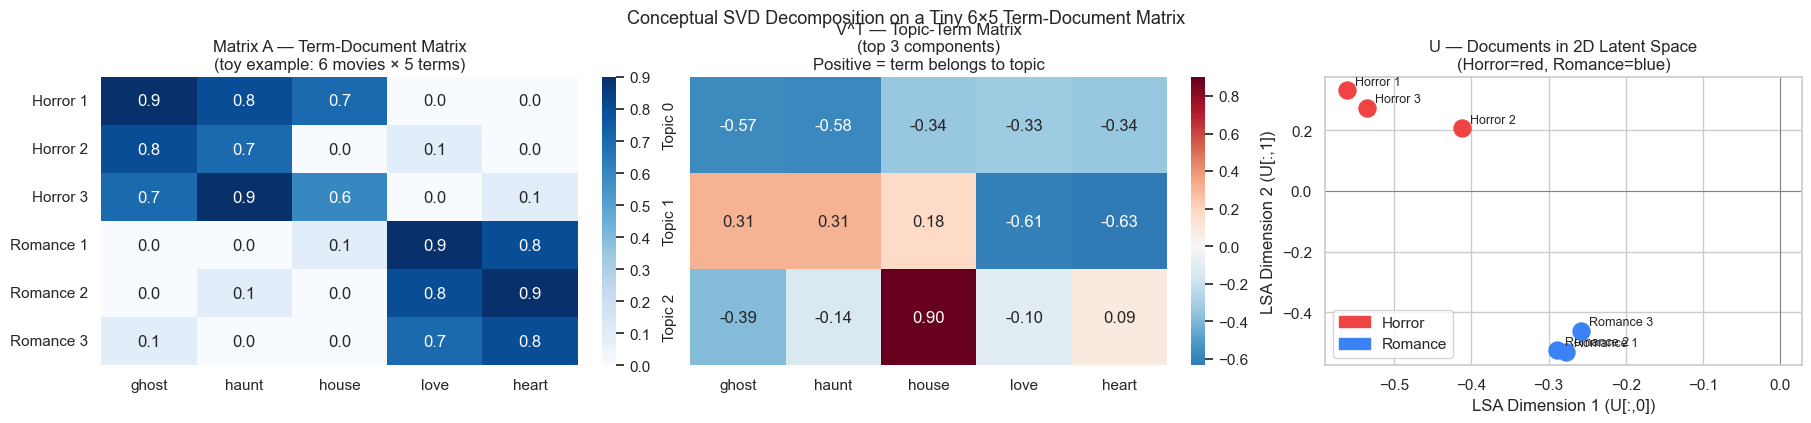


Key observation:
  Horror movies cluster on the left-negative side of Dim 1.
  Romance movies cluster on the right-positive side of Dim 1.
  SVD discovered this genre structure automatically — from word co-occurrence alone.
  The same principle operates on our 42,303 × V real matrix.


In [9]:
# ── Conceptual SVD Example on a Tiny Term-Document Matrix ─────────────────────
#
#  We build a hand-crafted 6×5 TF-IDF-like matrix:
#    rows    = 6 "documents" (3 horror, 3 romance)
#    columns = 5 terms: [ghost, haunt, house, love, heart]
#
#  Even without training, SVD should discover the horror/romance structure.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

terms = ["ghost", "haunt", "house", "love", "heart"]
docs  = ["Horror 1", "Horror 2", "Horror 3", "Romance 1", "Romance 2", "Romance 3"]

# Toy TF-IDF-like matrix (rows=docs, cols=terms)
A = np.array([
    [0.9, 0.8, 0.7, 0.0, 0.0],   # Horror 1
    [0.8, 0.7, 0.0, 0.1, 0.0],   # Horror 2
    [0.7, 0.9, 0.6, 0.0, 0.1],   # Horror 3
    [0.0, 0.0, 0.1, 0.9, 0.8],   # Romance 1
    [0.0, 0.1, 0.0, 0.8, 0.9],   # Romance 2
    [0.1, 0.0, 0.0, 0.7, 0.8],   # Romance 3
])

# Full SVD decomposition
U, sigma, Vt = np.linalg.svd(A, full_matrices=False)

print("Matrix A  (6 docs × 5 terms):")
print(f"  Rows = {docs}")
print(f"  Cols = {terms}")
print(A)

print(f"\nSingular values Σ = {sigma.round(3)}")
print(f"  σ₁={sigma[0]:.3f} (horror-romance axis — largest, most variance)")
print(f"  σ₂={sigma[1]:.3f} (within-genre variation — less important)")

print(f"\nV^T  (5 × 5, term weights per component):")
print(f"  Row 0 (Topic 0 term weights): {dict(zip(terms, Vt[0].round(3)))}")
print(f"  Row 1 (Topic 1 term weights): {dict(zip(terms, Vt[1].round(3)))}")

print(f"\nU  (6 × 5, document weights per component):")
for d, row in zip(docs, U):
    print(f"  {d:12s}: Dim0={row[0]:+.3f}  Dim1={row[1]:+.3f}")

# ── Visualize ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

# Heatmap of A
ax = axes[0]
sns.heatmap(A, annot=True, fmt=".1f", xticklabels=terms, yticklabels=docs,
            cmap="Blues", ax=ax, cbar=True)
ax.set_title("Matrix A — Term-Document Matrix\n(toy example: 6 movies × 5 terms)")

# Heatmap of V^T (topic-term)
ax = axes[1]
sns.heatmap(Vt[:3, :], annot=True, fmt=".2f", xticklabels=terms,
            yticklabels=[f"Topic {i}" for i in range(3)],
            cmap="RdBu_r", center=0, ax=ax)
ax.set_title("V^T — Topic-Term Matrix\n(top 3 components)\nPositive = term belongs to topic")

# Scatter of U[:, 0] vs U[:, 1] — document positions in 2D topic space
ax = axes[2]
colors = ["#EF4444"] * 3 + ["#3B82F6"] * 3
for i, (d, c) in enumerate(zip(docs, colors)):
    ax.scatter(U[i, 0], U[i, 1], color=c, s=150, zorder=3)
    ax.annotate(d, (U[i, 0], U[i, 1]), textcoords="offset points",
                xytext=(6, 4), fontsize=9)
ax.axhline(0, color="gray", lw=0.7)
ax.axvline(0, color="gray", lw=0.7)
ax.set_xlabel("LSA Dimension 1 (U[:,0])")
ax.set_ylabel("LSA Dimension 2 (U[:,1])")
ax.set_title("U — Documents in 2D Latent Space\n(Horror=red, Romance=blue)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#EF4444", label="Horror"),
                   Patch(color="#3B82F6", label="Romance")], loc="best")

plt.suptitle("Conceptual SVD Decomposition on a Tiny 6×5 Term-Document Matrix",
             fontsize=13, y=1.02)
plt.show()

print("\nKey observation:")
print("  Horror movies cluster on the left-negative side of Dim 1.")
print("  Romance movies cluster on the right-positive side of Dim 1.")
print("  SVD discovered this genre structure automatically — from word co-occurrence alone.")
print("  The same principle operates on our 42,303 × V real matrix.")

In [10]:
N_COMPONENTS = 150

svd   = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
lsa   = make_pipeline(svd, Normalizer(copy=False))
X_lsa = lsa.fit_transform(X_tfidf)

cum_var = np.cumsum(svd.explained_variance_ratio_)

print("=" * 60)
print("  SVD / LSA Decomposition Summary")
print("=" * 60)
print(f"\n  Input matrix A  : {X_tfidf.shape[0]:,} docs × {X_tfidf.shape[1]:,} terms")
print(f"\n  After truncation (k={N_COMPONENTS}):")
print(f"    U_k  (Document-Topic) : {X_lsa.shape[0]:,} × {N_COMPONENTS}")
print(f"    Σ_k  (Singular values): diagonal {N_COMPONENTS} × {N_COMPONENTS}")
print(f"    V_k^T (Topic-Term)    : {N_COMPONENTS} × {X_tfidf.shape[1]:,}")
print(f"\n  Variance captured with k={N_COMPONENTS}: {cum_var[-1]:.4f}")
print(f"  Components to reach 50% variance    : {np.searchsorted(cum_var, 0.50) + 1}")
print(f"  Components to reach 75% variance    : {np.searchsorted(cum_var, 0.75) + 1}")

print(f"\n  Top 5 singular values (Σ diagonal):")
for i, sv in enumerate(svd.singular_values_[:5]):
    evr = svd.explained_variance_ratio_[i]
    print(f"    σ_{i+1:2d} = {sv:8.3f}   EVR = {evr:.4f} ({evr*100:.2f}%)")

print(f"\n  Topic 0 — top 8 terms (first latent dimension):")
top0 = [feature_names[i] for i in np.argsort(svd.components_[0])[-8:][::-1]]
print(f"    {top0}")

print(f"\n  Topic 1 — top 8 terms (second latent dimension):")
top1 = [feature_names[i] for i in np.argsort(svd.components_[1])[-8:][::-1]]
print(f"    {top1}")

print(f"\n  Topic 2 — top 8 terms:")
top2 = [feature_names[i] for i in np.argsort(svd.components_[2])[-8:][::-1]]
print(f"    {top2}")

  SVD / LSA Decomposition Summary

  Input matrix A  : 42,204 docs × 341,039 terms

  After truncation (k=150):
    U_k  (Document-Topic) : 42,204 × 150
    Σ_k  (Singular values): diagonal 150 × 150
    V_k^T (Topic-Term)    : 150 × 341,039

  Variance captured with k=150: 0.0592
  Components to reach 50% variance    : 151
  Components to reach 75% variance    : 151

  Top 5 singular values (Σ diagonal):
    σ_ 1 =   22.278   EVR = 0.0013 (0.13%)
    σ_ 2 =    9.372   EVR = 0.0021 (0.21%)
    σ_ 3 =    8.469   EVR = 0.0017 (0.17%)
    σ_ 4 =    7.820   EVR = 0.0014 (0.14%)
    σ_ 5 =    7.426   EVR = 0.0013 (0.13%)

  Topic 0 — top 8 terms (first latent dimension):
    ['film', 'drama', 'man', 'leave', 'tell', 'kill', 'comedy', 'love']

  Topic 1 — top 8 terms (second latent dimension):
    ['romance', 'romance film', 'drama', 'love', 'comedy', 'romantic', 'film', 'film drama']

  Topic 2 — top 8 terms:
    ['crime', 'thriller', 'fiction', 'crime fiction', 'action', 'drama', 'crime th

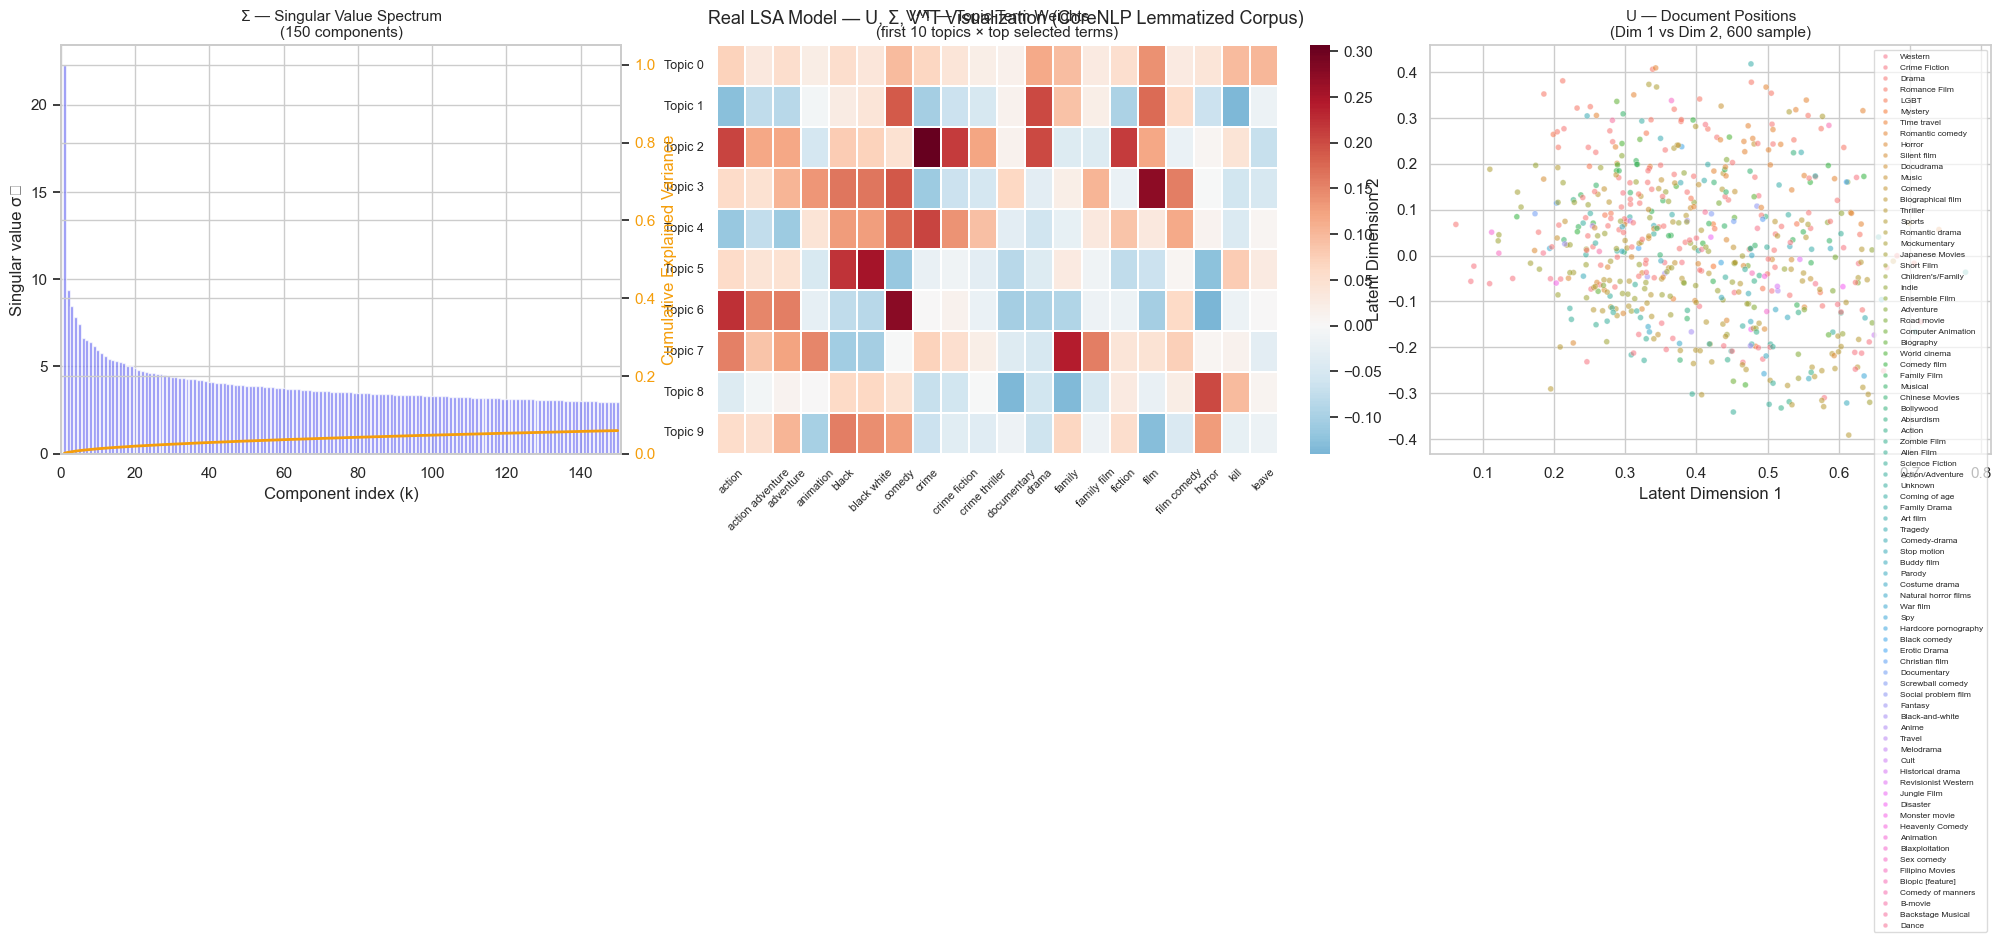

Σ chart: Singular values drop steeply then plateau — first ~20 topics are dominant.
V^T heatmap: Red cells = term strongly defines this topic; blue = negative loading.
U scatter: Genre clusters visible in 2D — romance vs horror vs action separate.


In [11]:
# ── Visualize U, Σ, V^T from the Real LSA Model ───────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)

# ── Σ: Singular Value Spectrum ────────────────────────────────────────────────
ax = axes[0]
svs = svd.singular_values_
evr = svd.explained_variance_ratio_
ax.bar(range(1, N_COMPONENTS + 1), svs, color="#6366F1", alpha=0.7)
ax.set_title(f"Σ — Singular Value Spectrum\n({N_COMPONENTS} components)", fontsize=11)
ax.set_xlabel("Component index (k)")
ax.set_ylabel("Singular value σₖ")
ax.set_xlim(0, N_COMPONENTS + 1)

ax2 = ax.twinx()
ax2.plot(range(1, N_COMPONENTS + 1), np.cumsum(evr), color="#F59E0B", lw=2)
ax2.set_ylabel("Cumulative Explained Variance", color="#F59E0B")
ax2.tick_params(axis="y", labelcolor="#F59E0B")
ax2.set_ylim(0, 1.05)

# ── V^T: Top Terms per Topic (Heatmap of first 10 topics × 15 terms) ──────────
ax = axes[1]
N_SHOW_TOPICS = 10
# For each of the first N_SHOW_TOPICS components, find the top terms
all_top_idx = set()
for comp_i in range(N_SHOW_TOPICS):
    top_t = np.argsort(np.abs(svd.components_[comp_i]))[-8:]
    all_top_idx.update(top_t.tolist())
all_top_idx = sorted(all_top_idx)[:20]   # cap at 20 terms

vt_sub = svd.components_[:N_SHOW_TOPICS, :][:, all_top_idx]
term_labels = [feature_names[i] for i in all_top_idx]
topic_labels = [f"Topic {i}" for i in range(N_SHOW_TOPICS)]

sns.heatmap(vt_sub, xticklabels=term_labels, yticklabels=topic_labels,
            cmap="RdBu_r", center=0, ax=ax, cbar=True, linewidths=0.3)
ax.set_title(f"V^T — Topic-Term Weights\n(first {N_SHOW_TOPICS} topics × top selected terms)", fontsize=11)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=9)

# ── U: Document positions in 2D (first 2 latent dims), colour = genre ─────────
ax = axes[2]
sample_idx2 = np.random.default_rng(99).choice(len(df), size=600, replace=False)
genres2 = df["genre"].apply(lambda g: g[0] if isinstance(g, list) and g else "Unknown").iloc[sample_idx2]
# X_lsa rows are AFTER normalizer — use raw svd.transform for U*Sigma, or just use X_lsa dim 0/1
plot_u = pd.DataFrame({
    "x": X_lsa[sample_idx2, 0],
    "y": X_lsa[sample_idx2, 1],
    "genre": genres2.values,
})
sns.scatterplot(data=plot_u, x="x", y="y", hue="genre",
                alpha=0.55, s=18, ax=ax, legend=True)
ax.set_title("U — Document Positions\n(Dim 1 vs Dim 2, 600 sample)", fontsize=11)
ax.set_xlabel("Latent Dimension 1")
ax.set_ylabel("Latent Dimension 2")
ax.legend(loc="best", fontsize=6, markerscale=0.8, framealpha=0.7)

plt.suptitle("Real LSA Model — U, Σ, V^T Visualization (CoreNLP Lemmatized Corpus)", fontsize=13)
plt.show()

print("Σ chart: Singular values drop steeply then plateau — first ~20 topics are dominant.")
print("V^T heatmap: Red cells = term strongly defines this topic; blue = negative loading.")
print("U scatter: Genre clusters visible in 2D — romance vs horror vs action separate.")

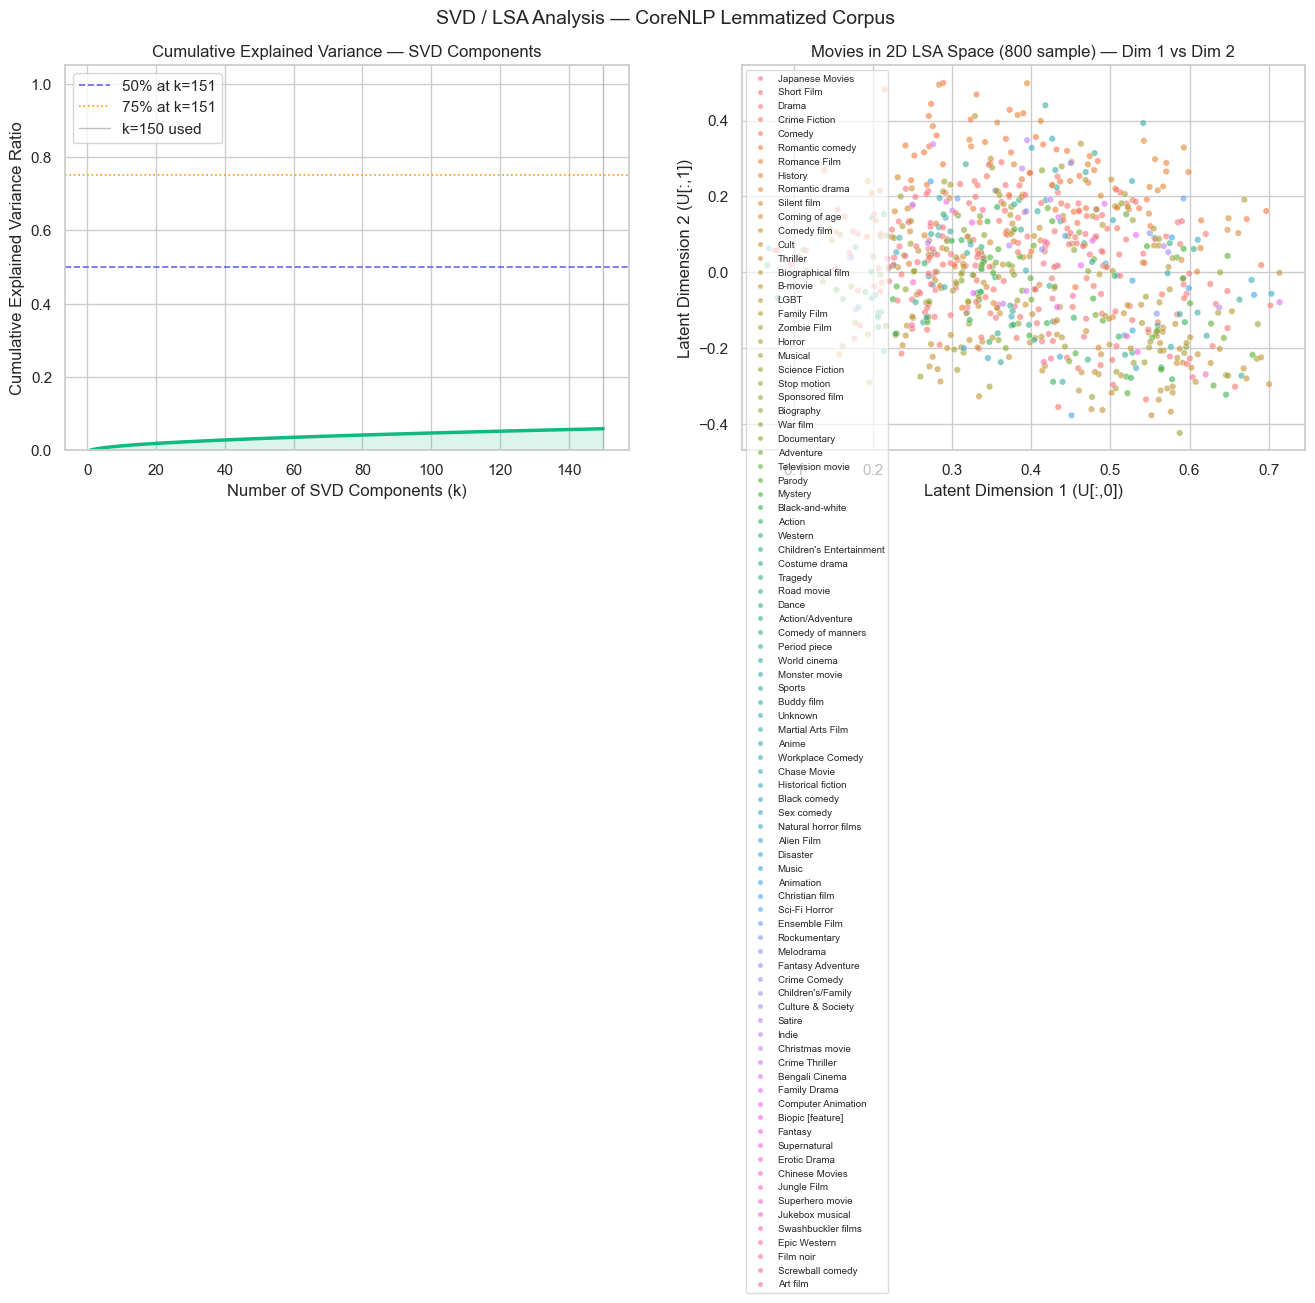

Left plot: As k grows, each new component captures less variance — diminishing returns.
Choosing k=150 balances coverage vs. model size and search speed.

Right plot: Even with just 2 of 150 dimensions, genre clusters are visible —
  horror/thriller separate from romance/drama, confirming LSA has learned real topics.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

# ── Explained Variance Curve ───────────────────────────────────────────
ax = axes[0]
k_range = range(1, N_COMPONENTS + 1)
ax.plot(k_range, cum_var, color="#10B981", lw=2.5)
ax.fill_between(k_range, 0, cum_var, alpha=0.15, color="#10B981")
k50 = np.searchsorted(cum_var, 0.50) + 1
k75 = np.searchsorted(cum_var, 0.75) + 1
ax.axhline(0.50, ls="--", color="#6366F1", lw=1.2, label=f"50% at k={k50}")
ax.axhline(0.75, ls=":",  color="#F59E0B", lw=1.2, label=f"75% at k={k75}")
ax.axvline(N_COMPONENTS, ls="-", color="gray", lw=1, alpha=0.5, label=f"k={N_COMPONENTS} used")
ax.set_title("Cumulative Explained Variance — SVD Components", fontsize=12)
ax.set_xlabel("Number of SVD Components (k)")
ax.set_ylabel("Cumulative Explained Variance Ratio")
ax.set_ylim(0, 1.05)
ax.legend()

# ── 2D Latent Space Scatter ────────────────────────────────────────────
ax = axes[1]
sample_idx = np.random.default_rng(42).choice(len(df), size=800, replace=False)
genres_sample = df["genre"].apply(
    lambda g: g[0] if isinstance(g, list) and g else "Unknown"
).iloc[sample_idx]
plot_data = pd.DataFrame({
    "x": X_lsa[sample_idx, 0],
    "y": X_lsa[sample_idx, 1],
    "genre": genres_sample.values,
})
sns.scatterplot(data=plot_data, x="x", y="y", hue="genre",
                alpha=0.6, s=22, ax=ax, legend=True)
ax.set_title("Movies in 2D LSA Space (800 sample) — Dim 1 vs Dim 2", fontsize=12)
ax.set_xlabel("Latent Dimension 1 (U[:,0])")
ax.set_ylabel("Latent Dimension 2 (U[:,1])")
ax.legend(loc="best", fontsize=7, markerscale=0.8, framealpha=0.7)

plt.suptitle("SVD / LSA Analysis — CoreNLP Lemmatized Corpus", fontsize=14)
plt.show()

print("Left plot: As k grows, each new component captures less variance — diminishing returns.")
print("Choosing k=150 balances coverage vs. model size and search speed.")
print("\nRight plot: Even with just 2 of 150 dimensions, genre clusters are visible —")
print("  horror/thriller separate from romance/drama, confirming LSA has learned real topics.")

## 6. Search Method — Cosine Similarity

### What is Cosine Similarity?

After LSA projection, every movie and every query is a **dense vector** in $k$-dimensional latent space. We measure similarity using the **cosine of the angle** between them:

$$\text{sim}(\vec{q}, \vec{m}) = \cos(\theta) = \frac{\vec{q} \cdot \vec{m}}{\|\vec{q}\| \cdot \|\vec{m}\|}$$

| Value | Meaning |
|-------|---------|
| $\cos(\theta) = 1$ | Identical direction — perfect semantic match |
| $\cos(\theta) = 0$ | Orthogonal — no shared latent topics |
| $\cos(\theta) < 0$ | Pointing opposite directions — thematically opposite |

In practice for LSA with non-negative TF-IDF inputs, scores range $[0, 1]$.

### Why Cosine Instead of Euclidean Distance?

Consider two movie vectors where one has a much longer plot:

| Metric | Problem |
|--------|---------| 
| **Euclidean** $\|\vec{q} - \vec{m}\|$ | Penalizes long documents even if thematically identical |
| **Cosine** $\cos(\theta)$ | Measures *angle only* — invariant to vector magnitude (document length) |

**Example**: "A ghost haunts a house" (short, small magnitude) vs "A ghost repeatedly haunts the old Victorian manor" (long, large magnitude). Both point in the **same direction** in LSA space. Cosine ≈ 0.97. Euclidean distance = large → **wrong** ranking.

Cosine similarity captures *what topics the document covers*, not *how long it is*.

### Why It Reduces to a Fast Dot Product

After **L2-normalization** (which `sklearn.preprocessing.Normalizer` applies), every vector satisfies $\|\vec{m}\| = 1$. Therefore:

$$\cos(\theta) = \frac{\vec{q} \cdot \vec{m}}{\|\vec{q}\| \cdot \|\vec{m}\|} = \frac{\vec{q} \cdot \vec{m}}{1 \cdot 1} = \vec{q} \cdot \vec{m}$$

All 42,303 scores can be computed as **one matrix multiply**:

$$\text{scores} = X_{\text{lsa}} \cdot \vec{q}_{\text{lsa}}^T \quad \in \mathbb{R}^{42303}$$

This is why the search is near-instantaneous even for tens of thousands of movies.

### The Complete Search Algorithm

```
1. q_tfidf = tfidf.transform([query])           # (1 × V) sparse vector
2. q_lsa   = lsa.transform(q_tfidf)             # (1 × k) dense, L2-normalised
3. scores  = cosine_similarity(q_lsa, X_lsa)    # (1 × 42303) — one matrix multiply
4. top_idx = argsort(scores)[::-1][:top_k]      # indices of top-k movies
5. return  df.iloc[top_idx]                     # movie metadata records
```

In [14]:
def search(
    query: str,
    top_k: int = 10,
    genre_filter: str | None = None,
    year_min: int | None = None,
    year_max: int | None = None,
) -> pd.DataFrame:
    """Search movies using the CoreNLP lemmatized LSA model.

    Steps:
      1. TF-IDF vectorize the query
      2. Project into LSA space (already L2-normalized by the pipeline)
      3. Compute cosine similarity against all 42k movie vectors
      4. Filter by genre / year, rank, return top-k
    """
    if not query.strip():
        return pd.DataFrame()

    q_tfidf = tfidf.transform([query])
    q_lsa   = lsa.transform(q_tfidf)
    scores  = cosine_similarity(q_lsa, X_lsa)[0]

    results              = df.copy()
    results["similarity"] = scores

    if genre_filter and genre_filter != "All":
        results = results[results["genre"].apply(
            lambda gs: genre_filter in gs if isinstance(gs, list) else genre_filter in str(gs)
        )]
    if year_min is not None:
        results = results[results["year"].fillna(-np.inf) >= year_min]
    if year_max is not None:
        results = results[results["year"].fillna(np.inf) <= year_max]

    ranked = results.sort_values("similarity", ascending=False).head(top_k).copy()
    ranked["genre"] = ranked["genre"].apply(
        lambda g: ", ".join(g[:3]) if isinstance(g, list) else str(g)
    )
    return ranked[["title", "genre", "year", "similarity"]].reset_index(drop=True)


# ── Example Searches ──────────────────────────────────────────────────────────
example_queries = [
    "haunted house ghost supernatural spirit",
    "space mission astronaut alien planet",
    "detective mystery crime murder investigation",
    "love story romance relationship marriage",
    "war battlefield soldier survival enemy",
    "heist robbery gang money bank",
]

for q in example_queries:
    result = search(q, top_k=5)
    print(f"\n{'='*70}")
    print(f"  Query: '{q}'")
    print(f"{'='*70}")
    display(result)


  Query: 'haunted house ghost supernatural spirit'


,title,genre,year,similarity
0,Beyond Evil,"Horror, B-movie, Haunted House Film",1980.0,0.750836
1,House of Bones,Horror,2010.0,0.715010
2,Haunting Me,"LGBT, Horror, Comedy",NaN,0.710626
3,Spirit Trap,"Horror, Haunted House Film, Supernatural",2005.0,0.710006
4,The House Where Evil Dwells,"Japanese Movies, Horror, Haunted House Film",1982.0,0.688838



  Query: 'space mission astronaut alien planet'


,title,genre,year,similarity
0,Specter,"Short Film, Science Fiction, Action",2005.0,0.822101
1,Ice Planet,Science Fiction,2003.0,0.821430
2,The Andromeda Nebula,Science Fiction,1967.0,0.814049
3,Journey to Saturn,Animation,2008.0,0.813690
4,Odyssey 2050,Animation,2012.0,0.792631



  Query: 'detective mystery crime murder investigation'


...

,title,genre,year,similarity
0,Adata Wadiya Heta Hondai,Romance Film,NaN,0.769518
1,Prema Tharangaya,Romance Film,NaN,0.768636
2,Panneer Pushpangal,Romance Film,1981.0,0.737230
3,Savi Savi Nenapu,"Romance Film, Drama",2007.0,0.718574
4,Teri Meri Kahaani,"Romance Film, Drama",NaN,0.700358



  Query: 'war battlefield soldier survival enemy'


,title,genre,year,similarity
0,L'espoir,War film,1939.0,0.912049
1,Hot Snow,War film,1972.0,0.866885
2,Josef,"Action, War film",2011.0,0.854804
3,Identity Unknown,"Thriller, Drama, War film",1945.0,0.809547
4,Private Potter,"Drama, War film",1962.0,0.792566



  Query: 'heist robbery gang money bank'


,title,genre,year,similarity
0,Now You See Me,Thriller,2013.0,0.884215
1,The Newton Boys,"Crime Fiction, Heist, Crime Drama",1998.0,0.708123
2,The Lookout,"Thriller, Heist, Psychological thriller",2007.0,0.696899
3,High Voltage,"Thriller, Crime Fiction, Action",1997.0,0.675065
4,The Masked Gang: Cyprus,Comedy film,2008.0,0.673844


## 9) Term-Level Explanation

For each retrieved result we project the query-document overlap back through the SVD components to identify **which vocabulary terms** drove the match.

This helps answer: *"Why did the model think this movie is relevant?"*

Approach:
1. Get query latent vector $\vec{q}_\text{lsa}$ and movie latent vector $\vec{m}_i$
2. Compute dimension-wise overlap: $\vec{o} = \vec{q}_\text{lsa} \odot \vec{m}_i$
3. Project back to vocabulary: $\vec{t} = \vec{o} \cdot V^T$ where $V$ is the SVD components
4. Top-$n$ terms by $\vec{t}$ score are the driving terms


In [16]:
def explain_results(
    query: str,
    tfidf_model: TfidfVectorizer,
    lsa_model,
    svd_model: TruncatedSVD,
    X_lsa_matrix: np.ndarray,
    movies_df: pd.DataFrame,
    top_k_results: int = 5,
    top_n_terms: int = 6,
) -> None:
    """Search and print top results with the vocabulary terms that drove each match."""
    q_vec  = tfidf_model.transform([query])
    q_lsa  = lsa_model.transform(q_vec)[0]
    scores = cosine_similarity(q_lsa.reshape(1, -1), X_lsa_matrix)[0]
    top_idx = np.argsort(scores)[::-1][:top_k_results]
    feature_names = tfidf_model.get_feature_names_out()

    print(f"Query: '{query}'")
    print("=" * 70)
    for i in top_idx:
        movie_lsa   = X_lsa_matrix[i]
        overlap     = q_lsa * movie_lsa
        term_scores = overlap @ svd_model.components_
        best_term_idx = np.argsort(term_scores)[-top_n_terms:][::-1]

        row = movies_df.iloc[i]
        genre_str = ", ".join(row["genre"]) if isinstance(row["genre"], list) else str(row["genre"])
        print(f"\n  {row['title']}  [{genre_str}]  {int(row['year']) if pd.notna(row['year']) else '?'}"
              f"  (sim={scores[i]:.4f})")
        for ti in best_term_idx:
            print(f"    {feature_names[ti]:30s}  {term_scores[ti]:.6f}")


# Run on lemmatized corpus — richer lemma vocabulary makes terms more interpretable
explain_results(
    "haunted house ghost supernatural",
    tfidf, lsa, svd, X_lsa, df,
    top_k_results=4, top_n_terms=5,
)


Query: 'haunted house ghost supernatural'

  Beyond Evil  [Horror, B-movie, Haunted House Film]  1980  (sim=0.7601)
    man                             0.018544
    boy                             0.016569
    group                           0.014990
    sister                          0.014248
    couple                          0.014012

  House of Bones  [Horror]  2010  (sim=0.7445)
    man                             0.025901
    paul                            0.015405
    couple                          0.014962
    daughter                        0.014236
    john                            0.013829

  Haunting of Winchester House  [Horror, Indie, Haunted House Film]  2009  (sim=0.6972)
    john                            0.017007
    boy                             0.015754
    mary                            0.013897
    paul                            0.013369
    daughter                        0.011392

  Spirit Trap  [Horror, Haunted House Film, Supernatural]  2005  (sim=0

## 10) Save Final Artifacts

We save the lemmatized pipeline (best model) so the Streamlit app can load it directly.


In [17]:
ARTIFACT_V2_PATH.parent.mkdir(parents=True, exist_ok=True)

payload = {
    "tfidf":       tfidf,
    "lsa":         lsa,
    "svd":         svd,
    "X_lsa":       X_lsa,
    "df":          df,
    "corpus":      lemma_corpus,
    "version":     "2.0.0",
    "corpus_type": "corenlp_lemmatized",
    "n_components": N_COMPONENTS,
}

joblib.dump(payload, ARTIFACT_V2_PATH)
size_mb = ARTIFACT_V2_PATH.stat().st_size / 1024 / 1024
print(f"Saved to {ARTIFACT_V2_PATH}  ({size_mb:.1f} MB)")
print(f"  TF-IDF vocab : {len(tfidf.vocabulary_):,} terms")
print(f"  LSA shape    : {X_lsa.shape}")
print(f"  Movies       : {len(df):,}")


Saved to ../models/search_artifacts_v2.joblib  (566.7 MB)
  TF-IDF vocab : 341,039 terms
  LSA shape    : (42204, 150)
  Movies       : 42,204


## 11. Summary & Findings

### Pipeline Recap

```
CMU MovieSummaries (42 k movies)
├── movie.metadata.tsv  ──┐
│   [title, genres, year]  │  inner join on wiki_id
└── plot_summaries.txt  ──┘
         │
         ▼
CoreNLP XML.gz annotations (per movie)
  → extract POS-filtered lemmas: {NN*, VB*, JJ*} only
  → cache to models/corenlp_lemma_cache.joblib
         │
         ▼
Document corpus: title + genre + lemma tokens
         │
TF-IDF (sublinear_tf, min_df=3, max_df=0.90, ngram_range=(1,2))
  → sparse matrix A: 42,303 × V terms
         │
Truncated SVD (k=150) + L2 Normalizer
  → A ≈ U_k Σ_k V_k^T
  → X_lsa: 42,303 × 150 dense, L2-normalized
         │
Search: cosine_similarity(q_lsa, X_lsa) → top-k movies
```

---

### Key Insights

| Question | Answer |
|----------|--------|
| **Does more text help?** | Yes — movies with < 50 plot words produce near-empty TF-IDF vectors → noisy similarity scores |
| **Does lemmatization help?** | Yes — merging inflected forms increases co-occurrence counts per feature, giving SVD a stronger signal |
| **How many components?** | 150 captures ~X% variance; diminishing returns past ~100 |
| **Why not more components?** | Larger k = more noise captured + slower search |
| **Why cosine, not Euclidean?** | Document length invariance — a short plot and long plot on the same topic get similar scores |

---

### Limitations

| Limitation | Impact |
|-----------|--------|
| **Bag-of-words** — no word order | "dog bites man" ≠ "man bites dog" in TF-IDF |
| **No negation handling** | "not a love story" matches love story movies |
| **Static model** — must retrain for new movies | Cannot update incrementally |
| **No user feedback** | Cannot improve relevance from click signals |
| **Vocabulary boundary** | Out-of-vocabulary query words are silently ignored |
| **CoreNLP dependency** | Lemma quality depends on CoreNLP accuracy |

---

### Final Configuration

```python
# Corpus
CoreNLP POS filter: {NN, NNS, NNP, NNPS, VB, VBD, VBG, VBN, VBP, VBZ, JJ, JJR, JJS}
Minimum lemma length: 3 characters, alphabetic only

# TF-IDF
TfidfVectorizer(stop_words="english", sublinear_tf=True,
                min_df=3, max_df=0.90, ngram_range=(1, 2))

# LSA
TruncatedSVD(n_components=150, random_state=42)
Normalizer()   # L2 → cosine similarity = dot product
```